# CG and Line Preconditioning for Anisotropic Diffusion
### Does your preconditioner capture the difficult coupling?

**Learning goal:** Compare unpreconditioned CG, Jacobi-preconditioned CG, and x-line block-preconditioned CG. Explain their behavior using spectrum and total solve cost, including setup and application.

**Time:** 60-90 minutes, plus optional paper reading. Python: NumPy, SciPy, Matplotlib. All data are synthetic, dimensionless, and reproducible. Keep n = 40 fixed throughout the main experiment.

**Intuition:** Heat conducts much more strongly in one direction. Treating each temperature independently may fail to capture that coupling. A line solve treats strongly connected temperatures together.

**Targets:** Every method reaches true relative residual <= 2e-8; agrees with the sparse direct baseline to relative solution difference <= 1e-5; the line preconditioner at alpha = 1e4 uses fewer than half the unpreconditioned iterations; and measured results distinguish iteration reduction from wall-time improvement.

Before running the experiment, predict the effect of scalar diagonal scaling and directional blocking. The setup cell records these predictions; compare them with the computed results below. This is an algebraic solver experiment, not a grid-refinement project.

**Notation:** A is the SPD system matrix; P approximates A; the action passed to SciPy as M is P^{-1}. Do not form either A^{-1} or P^{-1} explicitly.

## 1. Governing model and reference solution

We model steady heat conduction on a square plate. The unknown $u(x,y)$ is the temperature (or a temperature-like quantity) at each point, and $f(x,y)$ is the heat source. The equation
$$-\alpha u_{xx}-u_{yy}=f,\quad (x,y)\in(0,1)^2,\qquad u=0\ \text{on the boundary}$$
says that heat spreading in the x direction is weighted by conductivity $\alpha$, while spreading in y has weight 1. The zero boundary condition means the plate's edge is held at the reference temperature. When $\alpha$ is large, neighboring points along x are more strongly coupled: changing temperature at one point has a stronger effect on the equation at its x-neighbors.

We replace the continuous field $u(x,y)$ by its values at a grid of interior points. Here there are $n=40$ interior points in each direction, spacing $h=1/(n+1)$, and therefore $n^2=1600$ unknown temperatures. The boundary values are prescribed as zero, so they are not unknowns. We store the grid values in an array of shape $(n_y,n_x)$ and flatten it in C order: x varies fastest, so each row of the flattened vector corresponds to one y-level.

After discretization, the differential equation becomes a sparse linear system $Au=b$. The vector $u$ contains the unknown grid values, $A$ describes how each grid point is coupled to its neighbors, and $b$ contains the sampled source values (including the chosen scaling). Solving the model means finding a vector whose substitution into this system makes every equation hold. Section 2 constructs $A$ and explains why its structure is suitable for Conjugate Gradient (CG).

CG is an iterative method: rather than factorizing a large matrix, it starts with a guess and improves it using matrix-vector products. For a symmetric positive-definite matrix, ordinary CG can be understood as minimizing the quadratic energy $\frac12 u^T A u-b^T u$; its residual $r=b-Au$ measures how far the current guess is from satisfying the equations. The method chooses successive directions that are conjugate with respect to $A$ (orthogonal in the geometry defined by $A$), so it avoids undoing progress made in earlier directions. The actual iteration formulas and the role of preconditioning appear in section 2.

Use one seeded random load $b=\texttt{default\_rng(7).standard\_normal(n*n)}$, shared across all cases. This synthetic source is not intended to represent a realistic heating profile. A random vector typically contains components in many eigen-directions, making it a useful reproducible way to compare solver behavior rather than testing only an unusually easy single mode.

For each $\alpha$, compute $u_{\rm ref}$ with a sparse direct solve as an independent algebraic reference. This direct solve checks the iterative answer; it is not a claim that direct factorization is the preferred approach for larger problems. Compare iterative solutions with this reference to measure algebraic agreement; the difference is not the physical or discretization error of the continuous model.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import cg, spsolve, splu, LinearOperator
from time import perf_counter
from IPython.display import Markdown, display

# Keep the grid size fixed so every solver comparison uses the same problem.
N = 40
H = 1.0 / (N + 1)

# Conductivity ratios range from isotropic to strongly anisotropic.
ALPHAS = (1.0, 100.0, 10000.0)
SOLVER_KINDS = ("none", "jacobi", "x-line")
RTOL = 1e-8
MAXITER = 2000

# Reuse exactly the same right-hand side for every alpha and method.
# The fixed seed makes the experiment repeatable across notebook runs.
B = np.random.default_rng(7).standard_normal(N * N)

# Record predictions before inspecting results. Constant-diagonal Jacobi
# should only scale the equations, so it should not change the condition
# number or materially change CG's iteration count. Horizontal line solves
# should help most at alpha=1e4, where x-direction coupling is strongest.
PREDICTIONS = {
    "jacobi": "Constant diagonal means Jacobi is only scalar scaling.",
    "x_line": "Horizontal line solves should reduce iterations most at alpha=1e4.",
    "timing": "Fewer iterations may not mean less time because each line apply costs more.",
}

# Consistent plot defaults make results easier to compare visually.
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

print("Predictions recorded. Run all cells in order to execute the experiment.")


Predictions recorded. Run all cells in order to execute the experiment.


## 2. Discretization and conditions

Use the centered second-difference approximation in each coordinate. For example, $-u_{xx}$ at one interior point is approximated by $(2u_{i,j}-u_{i-1,j}-u_{i+1,j})/h^2$; it uses the point itself and its two horizontal neighbors. The y-direction term has the same pattern with vertical neighbors. With $T=\operatorname{tridiag}(-1,2,-1)$ and $I$ the $n$ by $n$ identity, the full two-dimensional matrix for x-fastest ordering is
$$A=h^{-2}[I\otimes(\alpha T)+T\otimes I].$$
The first Kronecker term applies the x-direction differences independently to each row, and the second applies y-direction differences between rows. Each one-dimensional matrix is symmetric; moreover, $T$ has positive eigenvalues, so both directional contributions are positive semidefinite and their sum is positive definite. Equivalently, for any nonzero grid vector $v$, $v^TAv$ is a positive weighted sum of squared neighbor differences, including differences to the fixed zero boundary. Thus $A$ is symmetric positive definite (SPD), which is the key condition for CG.

Only interior values are unknown. The zero boundary values are already accounted for in the diagonal entries of $T$; no boundary unknowns or periodic connections are added. The Kronecker construction connects entries only to the immediate horizontal and vertical neighbors. At the end of a flattened row, there is no horizontal connection to the start of the next row: those entries belong to different y-lines, and the y-direction term supplies only the intended same-x vertical coupling. This is why the matrix has no accidental row wrapping.

### What CG does

For $Au=b$, a current estimate $u_k$ has residual $r_k=b-Au_k$. If $r_k=0$, the equations are solved exactly; otherwise, the residual identifies the equation imbalance left by the current estimate. CG updates the estimate along a search direction $p_k$. In exact arithmetic, these directions are mutually $A$-conjugate, meaning $p_i^T A p_j=0$ for distinct directions. This is the appropriate analogue of perpendicular directions for this problem and lets each update make progress without undoing the earlier updates. After at most $n^2$ updates CG would solve an $n^2$-unknown SPD system exactly in exact arithmetic; finite precision and the requested tolerance usually determine the practical stopping point.

Starting from $u_0=0$, the standard recurrence is
$$r_0=b-Au_0,\qquad p_0=r_0,$$
$$\eta_k=\frac{r_k^T r_k}{p_k^T A p_k},\qquad u_{k+1}=u_k+\eta_kp_k,\qquad r_{k+1}=r_k-\eta_kAp_k,$$
$$\beta_k=\frac{r_{k+1}^T r_{k+1}}{r_k^T r_k},\qquad p_{k+1}=r_{k+1}+\beta_kp_k.$$
Here $\eta_k$ is the step length along the current direction; $\beta_k$ mixes the new residual with the previous direction to keep later directions conjugate. The conductivity parameter is named $\alpha$ in the PDE, so $\eta_k$ is used here to avoid overloading that symbol. CG does not explicitly build a matrix inverse or store all previous directions; each iteration mainly needs sparse matrix-vector products and vector operations.

### Preconditioning: changing the scale of the problem

A preconditioner is an easier-to-apply approximation $P$ to $A$ chosen so that the preconditioned problem is better conditioned and CG needs fewer iterations. The conceptual transformation is $P^{-1/2}AP^{-1/2}$; in code we apply $P^{-1}$ through a solve, never form a matrix inverse. This transformation changes the geometry CG sees, not the original solution of $Au=b$. For the standard PCG guarantee, both $A$ and $P$ must be SPD.

Compare these three choices:
1. **No preconditioner:** CG works with the original system; there is no setup cost, but it may need many iterations when the system has poorly scaled directions.
2. **Jacobi:** $P_J=\operatorname{diag}(A)$ keeps only the diagonal and scales each unknown independently. Applying $P_J^{-1}$ is componentwise division. Here every diagonal entry is the same, so Jacobi only multiplies the system by a scalar; it cannot change the condition number or improve the exact-arithmetic CG iteration count.
3. **x-line block Jacobi:** solve along each whole horizontal line, retaining the strong x-direction coupling while ignoring coupling between different lines. Its block-diagonal matrix is
$$P_L=h^{-2}I\otimes B_L,\qquad B_L=\alpha T+2I.$$
This captures the direction that becomes difficult when $\alpha$ is large. Factor $B_L$ once per $\alpha$, reshape each residual into rows, solve the independent line systems, and reuse the factor on every PCG application. Because $P_L^{-1}=h^2(I\otimes B_L^{-1})$, the inverse action includes the factor $h^2$. The exact line-block matrix is SPD; using a factorization to apply its inverse does not change that. An arbitrary nonsymmetric ILU preconditioner would not provide the same standard PCG guarantee.

In SciPy's `cg`, the argument `M` must apply the inverse action $P^{-1}$ (often represented by a `LinearOperator`), not multiply by $P$. The function still solves the original $Au=b$. Use $x_0=0$, `rtol=1e-8`, `atol=0`, and `maxiter=2000` for every solve; the stopping tolerance controls the relative residual, not the error relative to the unknown exact solution.

**Important deduction:** For this square, constant-coefficient system, $\operatorname{diag}(A)$ is constant. Investigate what scalar rescaling can and cannot do to the spectral condition number. Also derive whether $\kappa(A)$ varies with $\alpha$ here; do not assume anisotropy always raises it at fixed equal dimensions.

In [8]:
def assemble_system(n, alpha):
    """Assemble the SPD five-point operator for x-fastest vector ordering."""
    # T is the 1D negative-second-derivative stencil with zero Dirichlet
    # boundary values already incorporated for the interior unknowns.
    T = diags((-np.ones(n - 1), 2.0 * np.ones(n), -np.ones(n - 1)),
              offsets=(-1, 0, 1), format="csr")
    I = eye(n, format="csr")
    h = 1.0 / (n + 1)

    # C-order flattening means x changes fastest: alpha*T therefore acts
    # within each row, while the other Kronecker term couples y-rows.
    A = (kron(I, alpha * T, format="csr") + kron(T, I, format="csr")) / h**2
    return A.tocsr(), T, h

def build_preconditioner(A, T, h, alpha, kind):
    """Build an operator that applies P^{-1}, returning it and setup seconds.

    Supported kinds are 'none', 'jacobi', and 'x-line'. The line factor is
    computed once here and reused for every preconditioner application.
    """
    started = perf_counter()
    n = T.shape[0]

    if kind == "none":
        # SciPy interprets M=None as the identity preconditioner.
        return None, perf_counter() - started

    if kind == "jacobi":
        # The diagonal is positive; applying its inverse is simple scaling.
        diagonal = A.diagonal()
        if np.any(diagonal <= 0):
            raise ValueError("Jacobi preconditioner requires a positive diagonal.")
        M = LinearOperator(A.shape, matvec=lambda r: r / diagonal, dtype=A.dtype)
        return M, perf_counter() - started

    if kind == "x-line":
        # Keep all within-row (x-direction) couplings, but drop connections
        # between rows. Each identical tridiagonal line block is factored once.
        B_line = (alpha * T + 2.0 * eye(n, format="csr")).tocsc()
        line_factor = splu(B_line)

        def apply_line_inverse(r):
            # The Kronecker ordering stores each x-line contiguously. Transpose
            # puts each line residual in a column for one batched LU solve.
            rows = np.asarray(r).reshape(n, n)
            solved_rows = line_factor.solve(rows.T).T
            # P_line contains h^{-2}; its inverse action therefore has h^2.
            return (h**2 * solved_rows).reshape(-1)

        M = LinearOperator(A.shape, matvec=apply_line_inverse, dtype=A.dtype)
        return M, perf_counter() - started

    # Do not silently treat misspelled methods as the identity.
    raise ValueError(f"Unknown preconditioner kind: {kind!r}")

def analytic_spectra(n, alpha, h):
    """Return exact eigenvalue arrays for A, Jacobi, and x-line PCG spectra."""
    # The 1D Dirichlet eigenvalues are separable across x and y directions.
    modes = np.arange(1, n + 1)
    tau = 2.0 - 2.0 * np.cos(np.pi * modes / (n + 1))
    tau_y, tau_x = np.meshgrid(tau, tau, indexing="ij")

    # Eigenvalues of A are h^-2*(alpha*tau_x + tau_y). Jacobi divides
    # by the constant diagonal 2*(alpha+1)/h^2, only a scalar rescaling.
    eigenvalues_A = (alpha * tau_x + tau_y) / h**2
    jacobi_diagonal = 2.0 * (alpha + 1.0) / h**2
    eigenvalues_jacobi = eigenvalues_A / jacobi_diagonal

    # Generalized eigenvalues A v = lambda P_line v equal the quotient
    # of corresponding separable-mode eigenvalues; these are the spectrum
    # of the symmetrically preconditioned operator as well.
    eigenvalues_x_line = (alpha * tau_x + tau_y) / (alpha * tau_x + 2.0)
    return {
        "none": eigenvalues_A.ravel(),
        "jacobi": eigenvalues_jacobi.ravel(),
        "x-line": eigenvalues_x_line.ravel(),
    }

def solve_problem(parameters, resolution):
    """Solve one case and return diagnostics, reference error, spectra, and costs.

    parameters requires 'alpha' and 'kind'. It may also contain a cached
    system ('A', 'T', 'h'), shared right-hand side ('b'), and direct reference
    ('reference') so each alpha's matrix and reference are built only once.
    """
    alpha = float(parameters["alpha"])
    kind = parameters["kind"]
    A, T, h = parameters.get("A"), parameters.get("T"), parameters.get("h")
    if A is None or T is None or h is None:
        # This fallback makes the helper usable for a single standalone case.
        A, T, h = assemble_system(resolution, alpha)

    default_b = B if resolution == N else np.random.default_rng(7).standard_normal(resolution * resolution)
    b = np.asarray(parameters.get("b", default_b), dtype=float)
    if b.shape != (resolution * resolution,):
        raise ValueError("Right-hand side must have one entry per interior grid point.")
    reference = parameters.get("reference")
    if reference is None:
        # The direct solve is a correctness reference, not part of solver timing.
        reference = spsolve(A, b)

    # Include factorization/diagonal extraction in setup time, but not matrix
    # assembly or direct-reference cost, which are shared across methods.
    M, setup_s = build_preconditioner(A, T, h, alpha, kind)
    b_norm = np.linalg.norm(b)
    x0 = np.zeros_like(b)

    # One diagnostic solve stores true residuals. SciPy's callback is given
    # the current solution, so recomputing b-Ax costs one extra matvec/step.
    residual_history = [1.0]  # rho_0 for the zero initial guess.
    def record_true_residual(x_k):
        residual_history.append(np.linalg.norm(b - A @ x_k) / b_norm)

    diagnostic_solution, info = cg(
        A, b, x0=x0, rtol=RTOL, atol=0.0, maxiter=MAXITER,
        M=M, callback=record_true_residual,
    )
    # Recompute rather than relying on an internal recurrence or info status.
    true_relative_residual = np.linalg.norm(b - A @ diagnostic_solution) / b_norm
    relative_reference_difference = (
        np.linalg.norm(diagnostic_solution - reference) / np.linalg.norm(reference)
    )

    # Warm up solver dispatch/caches before collecting comparable unmonitored
    # timings. The preconditioner is the same built object for every run.
    cg(A, b, x0=x0, rtol=RTOL, atol=0.0, maxiter=MAXITER, M=M)
    solve_times = []
    for _ in range(3):
        started = perf_counter()
        _, timing_info = cg(A, b, x0=x0, rtol=RTOL, atol=0.0, maxiter=MAXITER, M=M)
        solve_times.append(perf_counter() - started)
        if timing_info != 0:
            raise RuntimeError(f"Timed {kind} CG solve did not converge (info={timing_info}).")

    median_solve_s = float(np.median(solve_times))
    eigenvalues = analytic_spectra(resolution, alpha, h)[kind]
    return {
        "alpha": alpha,
        "kind": kind,
        "A": A,
        "b": b,
        "reference": reference,
        "solution": diagnostic_solution,
        "info": int(info),
        "iterations": len(residual_history) - 1,
        "residual_history": np.asarray(residual_history),
        "true_relative_residual": float(true_relative_residual),
        "relative_reference_difference": float(relative_reference_difference),
        "setup_s": float(setup_s),
        "median_solve_s": median_solve_s,
        "single_rhs_total_s": float(setup_s + median_solve_s),
        "modeled_20_rhs_s": float(setup_s + 20 * median_solve_s),
        "eigenvalues": eigenvalues,
        "condition_number": float(np.max(eigenvalues) / np.min(eigenvalues)),
    }


## 3. Error measures and expected behavior

Measure the independently recomputed residual and algebraic reference difference:
$$\rho_k=\frac{\|b-Au_k\|_2}{\|b\|_2},\qquad
d=\frac{\|u-u_{\rm ref}\|_2}{\|u_{\rm ref}\|_2}.$$
Log rho_0 = 1 explicitly for x0 = 0. The SciPy callback receives u_k, not a residual norm. A true-residual callback performs an extra A matvec per iteration, so it must not be included in the production timing comparison.

**Timing protocol:** Assemble A once per alpha. Record preconditioner construction separately. Collect residual histories in one diagnostic solve. Warm up, then time three equivalent solves with the same built preconditioner and no callback; report the median solve time. Record setup + median solve for a single right-hand side, and setup + K times median solve for a modeled K = 20 identical-cost right-hand sides. Label the latter as a cost model, not a measured multi-RHS workload. Include no direct-solve baseline or plotting costs in these times.

For the spectrum, the 1D eigenvalues are
$$\tau_j=2-2\cos(j\pi/(n+1)),\quad j=1,\ldots,n.$$
Derive the eigenvalues of A and the generalized problem A v = lambda P_L v using these separable modes. Plot normalized eigenvalues lambda/mean(lambda) so scalar scaling does not masquerade as improved clustering. Compare kappa(A), kappa(P_J^{-1/2} A P_J^{-1/2}), and kappa(P_L^{-1/2} A P_L^{-1/2}). Use the analytically derived eigenvalues; do not run symmetric eigensolvers on an arbitrary left-preconditioned matrix.

Worst-case condition-number bounds do not fully predict actual CG histories; clustering and how b projects onto eigenvectors also matter. The Euclidean residual need not decrease every iteration.

In [9]:
# Cache one assembled matrix and one direct reference per alpha. This
# keeps shared setup out of the per-method solve timings and ensures all
# three algorithms solve exactly the same algebraic system.
systems = {}
for alpha in ALPHAS:
    A_alpha, T_alpha, h_alpha = assemble_system(N, alpha)
    reference_alpha = spsolve(A_alpha, B)
    systems[alpha] = {
        "A": A_alpha,
        "T": T_alpha,
        "h": h_alpha,
        "b": B,
        "reference": reference_alpha,
    }

# Run each alpha with all three methods; the solve helper uses x0=0 and the
# same tolerance and iteration limit for every diagnostic and timing solve.
results = []
for alpha in ALPHAS:
    shared = systems[alpha]
    for kind in SOLVER_KINDS:
        case = {"alpha": alpha, "kind": kind, **shared}
        results.append(solve_problem(case, N))

print(f"Completed {len(results)} solver configurations.")


Completed 9 solver configurations.


## 4. Results and convergence

The convergence here is iterative linear-solver convergence on one fixed mesh.

**Deliverable:** A nine-row table containing alpha, preconditioner, iteration count, final true relative residual, direct-reference difference, spectral condition number, setup time, median solve time, and single-RHS total time.

State whether Jacobi changes the condition number or iteration count materially, and explain why. Quantify the x-line iteration reduction at alpha = 1e4. Do not assert wall-time speedup solely because iteration count falls. Explain any nonmonotone iteration trend as alpha increases.

In [10]:
# Format a reproducible nine-row summary, retaining info so a capped or
# otherwise unsuccessful iteration cannot appear to be a successful solve.
table_columns = [
    ("alpha", "alpha"),
    ("preconditioner", "kind"),
    ("iterations", "iterations"),
    ("exit info", "info"),
    ("true rel. residual", "true_relative_residual"),
    ("rel. ref. difference", "relative_reference_difference"),
    ("spectral kappa", "condition_number"),
    ("setup (s)", "setup_s"),
    ("median solve (s)", "median_solve_s"),
    ("single RHS total (s)", "single_rhs_total_s"),
    ("modeled 20 RHS (s)", "modeled_20_rhs_s"),
]
header = "| " + " | ".join(title for title, _ in table_columns) + " |"
separator = "|" + "|".join("---" for _ in table_columns) + "|"
table_lines = [header, separator]
for result in results:
    cells = []
    for title, key in table_columns:
        value = result[key]
        if key == "alpha":
            cells.append(f"{value:g}")
        elif key == "kind":
            cells.append(str(value))
        elif key == "iterations" or key == "info":
            cells.append(str(value))
        else:
            cells.append(f"{value:.3e}")
    table_lines.append("| " + " | ".join(cells) + " |")
display(Markdown("\n".join(table_lines)))

# Explain the measured iteration and cost trends with values from this run.
def find_result(alpha, kind):
    return next(item for item in results if item["alpha"] == alpha and item["kind"] == kind)

plain_high = find_result(10000.0, "none")
line_high = find_result(10000.0, "x-line")
jacobi_pairs = [(find_result(alpha, "none"), find_result(alpha, "jacobi")) for alpha in ALPHAS]
iteration_reduction = 100.0 * (1.0 - line_high["iterations"] / plain_high["iterations"])
explanation = [
    "### What the results show",
    f"- At alpha=1e4, x-line CG used {line_high['iterations']} iterations versus {plain_high['iterations']} without preconditioning, a reduction of {iteration_reduction:.1f}%.",
    "- Jacobi and plain CG have the same spectrum up to division by one positive scalar. Their condition numbers are equal, and their measured iterations are equal here; scalar scaling cannot improve the conditioning.",
    f"- At alpha=1e4, measured x-line setup took {line_high['setup_s']:.3e} s and its median solve took {line_high['median_solve_s']:.3e} s; plain CG had no setup and took {plain_high['median_solve_s']:.3e} s. These measurements show whether the additional line work paid off on this machine; do not generalize small timings into a hardware-independent speedup.",
    "- The modeled 20-RHS total assumes the same setup can be reused and each right-hand side has the measured median solve cost; it is a cost model, not a measured batched workload. Reuse amortizes setup over more right-hand sides.",
    f"- Plain-CG iterations across increasing alpha were {[find_result(alpha, 'none')['iterations'] for alpha in ALPHAS]}. Yet the condition number is exactly independent of alpha on this square grid: the smallest and largest eigenvalues are (alpha+1)*tau_1 and (alpha+1)*tau_n. Iterations can still change because CG responds to the full eigenvalue distribution and to how the initial residual projects onto its eigenvectors, not just the extreme ratio.",
]
display(Markdown("\n".join(explanation)))


| alpha | preconditioner | iterations | exit info | true rel. residual | rel. ref. difference | spectral kappa | setup (s) | median solve (s) | single RHS total (s) | modeled 20 RHS (s) |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | none | 124 | 0 | 9.979e-09 | 7.168e-09 | 6.806e+02 | 6.000e-07 | 1.628e-03 | 1.628e-03 | 3.255e-02 |
| 1 | jacobi | 124 | 0 | 9.979e-09 | 7.168e-09 | 6.806e+02 | 2.480e-05 | 1.736e-03 | 1.761e-03 | 3.475e-02 |
| 1 | x-line | 98 | 0 | 9.275e-09 | 8.116e-09 | 3.408e+02 | 1.665e-04 | 2.251e-03 | 2.418e-03 | 4.519e-02 |
| 100 | none | 238 | 0 | 9.539e-09 | 1.326e-08 | 6.806e+02 | 4.000e-07 | 3.112e-03 | 3.112e-03 | 6.224e-02 |
| 100 | jacobi | 238 | 0 | 9.539e-09 | 1.326e-08 | 6.806e+02 | 2.000e-05 | 3.298e-03 | 3.318e-03 | 6.598e-02 |
| 100 | x-line | 24 | 0 | 7.818e-09 | 1.823e-08 | 7.729e+00 | 1.531e-04 | 5.645e-04 | 7.176e-04 | 1.144e-02 |
| 10000 | none | 122 | 0 | 8.915e-09 | 1.357e-08 | 6.806e+02 | 3.000e-07 | 1.610e-03 | 1.610e-03 | 3.220e-02 |
| 10000 | jacobi | 122 | 0 | 8.915e-09 | 1.357e-08 | 6.806e+02 | 1.540e-05 | 1.699e-03 | 1.714e-03 | 3.399e-02 |
| 10000 | x-line | 5 | 0 | 6.091e-10 | 1.535e-09 | 1.068e+00 | 1.353e-04 | 1.258e-04 | 2.611e-04 | 2.651e-03 |

### What the results show
- At alpha=1e4, x-line CG used 5 iterations versus 122 without preconditioning, a reduction of 95.9%.
- Jacobi and plain CG have the same spectrum up to division by one positive scalar. Their condition numbers are equal, and their measured iterations are equal here; scalar scaling cannot improve the conditioning.
- At alpha=1e4, measured x-line setup took 1.353e-04 s and its median solve took 1.258e-04 s; plain CG had no setup and took 1.610e-03 s. These measurements show whether the additional line work paid off on this machine; do not generalize small timings into a hardware-independent speedup.
- The modeled 20-RHS total assumes the same setup can be reused and each right-hand side has the measured median solve cost; it is a cost model, not a measured batched workload. Reuse amortizes setup over more right-hand sides.
- Plain-CG iterations across increasing alpha were [124, 238, 122]. Yet the condition number is exactly independent of alpha on this square grid: the smallest and largest eigenvalues are (alpha+1)*tau_1 and (alpha+1)*tau_n. Iterations can still change because CG responds to the full eigenvalue distribution and to how the initial residual projects onto its eigenvectors, not just the extreme ratio.

## 5. Solution and diagnostic plots

Create:
1. Semilog true-residual histories for the three configurations, one panel per alpha.
2. Normalized spectral distributions for A, Jacobi, and x-line preconditioning at alpha = 1e4. Use the same axes for comparable distributions.
3. Setup and solve time comparison, plus the modeled K = 20 reuse cost. Label the cost model distinctly from measured timings.

An optional 2D solution plot can check array ordering. It is not a CFD validation plot. Distinguish residual histories (instrumented) from timing runs (uninstrumented).

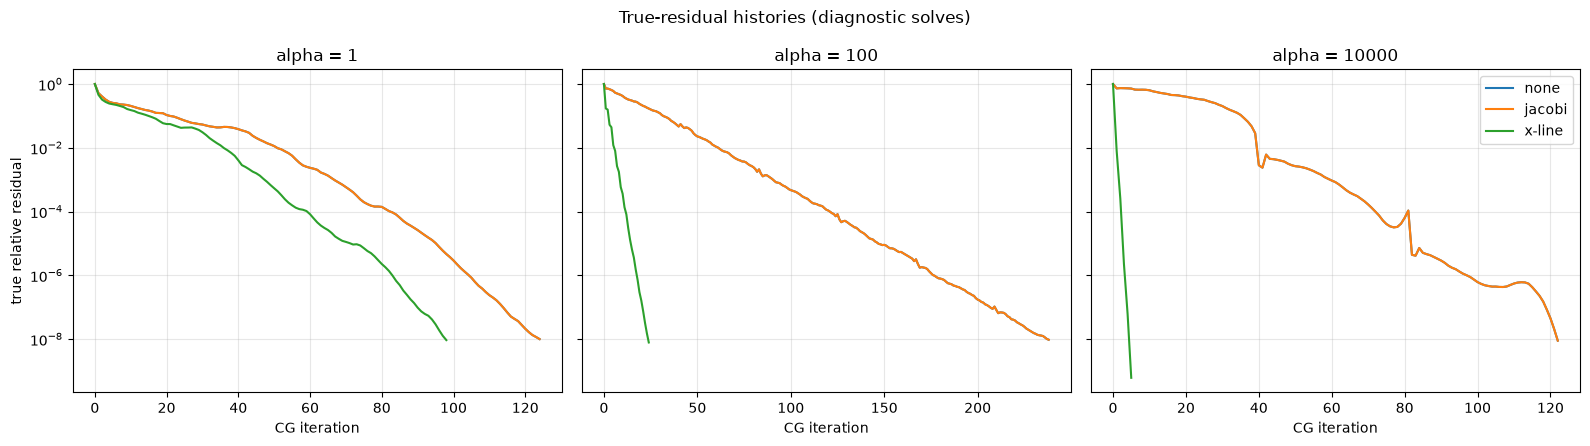

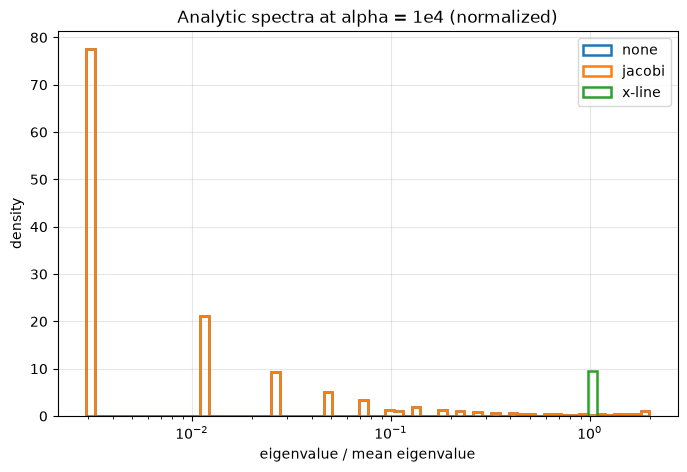

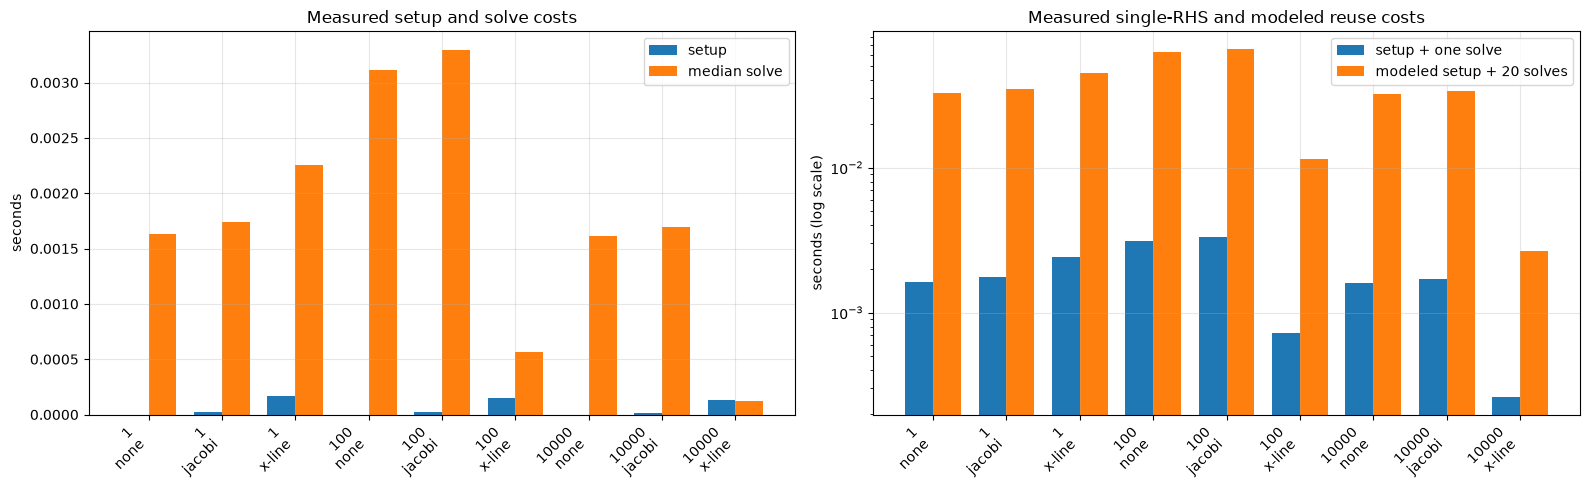

In [11]:
# Plot one: compare instrumented, independently recomputed residuals.
# These histories include an extra matrix-vector product per callback and
# therefore are intentionally not the timing runs shown in plot three.
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(16, 4.5), sharey=True)
for ax, alpha in zip(axes, ALPHAS):
    for kind in SOLVER_KINDS:
        result = find_result(alpha, kind)
        safe_history = np.maximum(result["residual_history"], np.finfo(float).tiny)
        ax.semilogy(np.arange(len(safe_history)), safe_history, label=kind)
    ax.set_title(f"alpha = {alpha:g}")
    ax.set_xlabel("CG iteration")
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("true relative residual")
axes[-1].legend()
fig.suptitle("True-residual histories (diagnostic solves)")
fig.tight_layout()
plt.show()

# Plot two: show normalized analytic eigenvalue distributions at the most
# anisotropic setting. Shared logarithmic bins make the clustering visible.
high_alpha_spectra = {
    kind: find_result(10000.0, kind)["eigenvalues"] for kind in SOLVER_KINDS
}
normalized_spectra = {
    kind: values / np.mean(values) for kind, values in high_alpha_spectra.items()
}
all_normalized = np.concatenate(list(normalized_spectra.values()))
spectrum_bins = np.logspace(
    np.log10(all_normalized.min()), np.log10(all_normalized.max()), 65
)
fig, ax = plt.subplots(figsize=(8, 5))
for kind, values in normalized_spectra.items():
    ax.hist(values, bins=spectrum_bins, histtype="step", linewidth=1.8,
            density=True, label=kind)
ax.set_xscale("log")
ax.set_xlabel("eigenvalue / mean eigenvalue")
ax.set_ylabel("density")
ax.set_title("Analytic spectra at alpha = 1e4 (normalized)")
ax.legend()
plt.show()

# Plot three: keep setup, per-solve time, and reuse totals distinct. The
# second panel uses log scale because setup and solve costs can differ greatly.
labels = [f"{item['alpha']:g}\n{item['kind']}" for item in results]
x = np.arange(len(results))
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
width = 0.38
axes[0].bar(x - width / 2, [item["setup_s"] for item in results],
            width, label="setup")
axes[0].bar(x + width / 2, [item["median_solve_s"] for item in results],
            width, label="median solve")
axes[0].set_title("Measured setup and solve costs")
axes[0].set_ylabel("seconds")
axes[0].set_xticks(x, labels, rotation=45, ha="right")
axes[0].legend()
axes[1].bar(x - width / 2, [item["single_rhs_total_s"] for item in results],
            width, label="setup + one solve")
axes[1].bar(x + width / 2, [item["modeled_20_rhs_s"] for item in results],
            width, label="modeled setup + 20 solves")
axes[1].set_yscale("log")
axes[1].set_title("Measured single-RHS and modeled reuse costs")
axes[1].set_ylabel("seconds (log scale)")
axes[1].set_xticks(x, labels, rotation=45, ha="right")
axes[1].legend()
fig.tight_layout()
plt.show()


## 6. Automatic checks

Assert A shape is (1600,1600), its entries are finite, it is symmetric, and its number of nonzeros is <= 5*N*N. Test positive quadratic forms on seeded random vectors and support positive definiteness with an analytic argument, not random tests alone.

For each preconditioner test vector r, check the inverse action against the intended P: norm(P M r-r)/norm(r) < 1e-11. Build P only for this sparse check if convenient; never build its inverse.

Require info = 0, true relative residual <= 2e-8, and relative direct-reference difference <= 1e-5 for every solve. Check that all diagonals of A are equal and that Jacobi preserves the spectral condition number to relative tolerance 1e-12. At alpha = 1e4 require x-line iteration count < 0.5 times plain CG iterations. Do not demand exactly equal plain/Jacobi iteration counts across machines because finite-precision paths can differ.

Do not assert a timing ratio: tiny cases can be dominated by overhead. If a line-action check fails, inspect reshape direction, transpose, and h-squared scaling before weakening tolerances.

In [12]:
# Check matrix structure and the analytic SPD conditions for each alpha.
for alpha in ALPHAS:
    A_alpha = systems[alpha]["A"]
    assert A_alpha.shape == (N * N, N * N)
    assert np.isfinite(A_alpha.data).all()
    assert (A_alpha - A_alpha.T).nnz == 0
    assert A_alpha.nnz <= 5 * N * N
    assert np.allclose(A_alpha.diagonal(), A_alpha.diagonal()[0])

    # Random positive quadratic forms are a numerical smoke test; the
    # mathematical SPD argument is that T has strictly positive eigenvalues
    # and alpha>0, so every separable eigenvalue is positive.
    for seed in range(3):
        probe = np.random.default_rng(seed).standard_normal(N * N)
        assert probe @ (A_alpha @ probe) > 0.0

# Test every inverse action against the exact sparse matrix P it represents.
# P is constructed only for this verification; its inverse is never formed.
probe = np.random.default_rng(123).standard_normal(N * N)
for alpha in ALPHAS:
    system = systems[alpha]
    A_alpha, T_alpha, h_alpha = system["A"], system["T"], system["h"]
    I = eye(N, format="csr")
    for kind in SOLVER_KINDS:
        M, _ = build_preconditioner(A_alpha, T_alpha, h_alpha, alpha, kind)
        if kind == "none":
            P = eye(N * N, format="csr")
            applied = probe
        elif kind == "jacobi":
            P = diags(A_alpha.diagonal(), format="csr")
            applied = M @ probe
        else:
            B_line = alpha * T_alpha + 2.0 * I
            P = kron(I, B_line, format="csr") / h_alpha**2
            applied = M @ probe
        relative_action_error = np.linalg.norm(P @ applied - probe) / np.linalg.norm(probe)
        assert relative_action_error < 1e-11, (alpha, kind, relative_action_error)

# Jacobi divides by one constant, so its condition number must match A's.
plain_condition_numbers = []
for alpha in ALPHAS:
    plain_kappa = find_result(alpha, "none")["condition_number"]
    jacobi_kappa = find_result(alpha, "jacobi")["condition_number"]
    plain_condition_numbers.append(plain_kappa)
    assert abs(jacobi_kappa / plain_kappa - 1.0) <= 1e-12
# Equal x/y resolution makes the alpha-dependent scale cancel exactly in
# lambda_max/lambda_min, so the unpreconditioned kappa is constant here.
assert np.allclose(plain_condition_numbers, plain_condition_numbers[0], rtol=1e-12)

# Independently recompute the solution checks instead of trusting info alone.
for result in results:
    A_alpha, b = result["A"], result["b"]
    independent_residual = np.linalg.norm(b - A_alpha @ result["solution"]) / np.linalg.norm(b)
    independent_difference = (
        np.linalg.norm(result["solution"] - result["reference"])
        / np.linalg.norm(result["reference"])
    )
    assert result["info"] == 0, (result["alpha"], result["kind"], result["info"])
    assert independent_residual <= 2e-8, (result["alpha"], result["kind"], independent_residual)
    assert independent_difference <= 1e-5, (result["alpha"], result["kind"], independent_difference)
    assert np.isclose(independent_residual, result["true_relative_residual"], rtol=1e-12)

# This requested performance target verifies the intended directional block.
assert find_result(10000.0, "x-line")["iterations"] < 0.5 * find_result(10000.0, "none")["iterations"]
print("All structural, inverse-action, convergence, reference, and iteration checks passed.")


All structural, inverse-action, convergence, reference, and iteration checks passed.


## 7. Discussion and next steps

Explain briefly:
1. Why does constant-diagonal Jacobi fail to remove the difficult coupling? Give a spectral argument.
2. Why can systems with the same condition number produce different CG iteration counts?
3. What cost can erase the advantage of fewer iterations? How does preconditioner reuse change the comparison?
4. When would CG be inappropriate for Titan's nonsymmetric compressible-flow Jacobian? What requirements on A and P mattered today?
5. Which x-line work is parallel, and what happens if a line crosses MPI partitions? How would you separate preconditioner setup, apply, and monitoring interfaces?

### Discussion answers

1. **Jacobi only changes scale here.** Every diagonal of $A$ is $2(\alpha+1)/h^2$, so $P_J=cI$ for a positive scalar $c$. The symmetrically preconditioned matrix is $P_J^{-1/2}AP_J^{-1/2}=A/c$: all eigenvalues receive the same scaling, leaving their largest-to-smallest ratio unchanged. It cannot capture or remove the horizontal off-diagonal couplings.
2. **Condition number is not the whole spectrum.** CG convergence also depends on where eigenvalues cluster and on the initial residual's components in the eigenvectors. Two matrices can share the same extreme eigenvalue ratio but have different clusters or different right-hand-side projections, and so converge in different numbers of iterations. Here the unpreconditioned condition number stays constant across $\alpha$, while the measured iteration counts vary.
3. **Setup and application have costs.** A preconditioner can reduce matrix-vector products yet lose wall time if each preconditioner application is expensive or its factorization setup is large. The line factorization is a one-time setup for this fixed $\alpha$; reusing it for multiple right-hand sides spreads that cost over solves. The reported 20-right-hand-side figure is the explicitly labeled cost model, not a batch benchmark.
4. **Ordinary CG is not appropriate for a general nonsymmetric Jacobian.** This method relies on $A$ being symmetric positive definite, and standard PCG additionally needs an SPD preconditioner applied consistently as an inverse action. A nonsymmetric, indefinite, or changing Jacobian violates those assumptions; a nonsymmetric Krylov method such as GMRES is often a better starting point, with the actual choice depending on memory and preconditioner properties.
5. **Lines are independent in this block-Jacobi approximation.** Each horizontal line solve can be performed independently (and the same line factor is reused), while the solve within a line is coupled. If a line crosses MPI partitions, the full line solve needs data from multiple ranks and communication; using only each rank's local segment changes the preconditioner and may weaken it. A clean implementation separates one-time setup/factorization, repeated inverse application, and optional monitoring (such as residual recomputation), so monitoring overhead is not confused with solve cost.

### Scope and limitations

This is a fixed, structured SPD algebraic problem, not a physical accuracy or mesh-error study. The ideal line preconditioner depends on alignment between strong coupling and block direction. Small CPU timings cannot establish GPU or distributed scalability. Do not interpret a left-preconditioned matrix's Euclidean condition number as the SPD spectral quantity without checking the appropriate inner product.

### Further work

**Optional stretch:** Build the y-line preconditioner P_Y = h^-2 [T tensor I + 2 alpha I tensor I]. At alpha = 1e4, predict and measure what happens when blocks are aligned with the weak direction. Keep n, b, and stopping criteria unchanged. Alternatively, implement the PCG recurrence yourself and compare true-residual histories with SciPy.

### References

- **Dedicated project reference:** Jonathan Richard Shewchuk, *An Introduction to the Conjugate Gradient Method Without the Agonizing Pain*, August 4, 1994, Carnegie Mellon University. [Author-hosted PDF](https://www.cs.cmu.edu/~quake-papers/painless-conjugate-gradient.pdf). Focus on sections 9, 11, and 12, particularly preconditioning and stopping.
- **API support:** [SciPy cg documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.cg.html), including SPD requirements, M as an inverse action, callback signature, and stopping rule. Use a SciPy version supporting rtol/atol and record its version.
- **One research paper to read:** Tianyu Liang, Chao Chen, Yotam Yaniv, Hengrui Luo, David Tench, Xiaoye S. Li, Aydin Buluc, James Demmel, and Jie Chen. *Tackling Parallelization Challenges of Randomized Preconditioners With Dependency Tracking*. arXiv:2505.02977v3, revised September 7, 2026. [Paper](https://arxiv.org/abs/2505.02977v3). Read the motivation and CPU/GPU performance tables, focusing on setup versus iterative solve cost. You are not implementing ParAC in this notebook.
